# RF2-B — Feature discriminability study

| 항목 | 값 |
|---|---|
| research_question | 존재하는 feature 와 구별력이 있는 feature 를 분리한다 |
| parent program | `RQ-D-RF-002` |
| child_id | `D-RF2-B` |
| hypothesis_id | `H-RF2-B-FEATURE-INFORMATION` |
| competing hypotheses | H-B1 대부분 feature 가 정보 없음 / H-B2 소수 feature 에 정보 집중 / H-B3 feature 들이 서로 중복이라 실효 차원이 작다 |
| input snapshot sha — `D_OBSERVATION_TABLE_v2.csv` | `c39c10f09f7a6a7603409550eb331612eb44634eb98ec387a604aa5221351e6b` |
| input snapshot sha — `D_TEXT_CORPUS_v2.csv` | `bf6bb772faa45541c780c75f5cbffa856783a34661a84e3de27a9eb5da4ea36a` |
| code sha — `tools/rf2_b_feature_discriminability.py` | `0c1aeef0216c62fb80c4d47b05f34473332be3c070bdf6a7c9cd50c40fbbe62e` |
| MLflow run_id | `6bcfe2bffbf54bab8ae3b4ba54dfed6a` |
| MLflow parent_run_id | `ae754858ba3a4be391e5f811640d3fd8` (experiment `LA_03_RF_MAPPING`) |
| n | **56** (grain: **target**, `in_mart == 1`) |
| grain | target |
| seed | `20260827` (permutations B=20000) |

## 라벨 의미 — 먼저 읽을 것

`prior_archetype` 은 **gold label 이 아니라 prior** 다. 이 노트북은 그것을 **exploratory
coloring / reference** 로만 쓴다. 어떤 분류기도 적합하지 않았고 prior 를 정답으로 학습하지
않았다. 아래 MI 는 `information_about_prior`, 조건부 prevalence 는 `prior_agreement` 의
서술이다. 정답이 없으므로 `accuracy` 는 정의되지 않고 이 노트북에 쓰지 않는다.

## 방화벽

이 노트북은 결과 JSON 하나만 읽는다. holdout label · `LABEL_SPLIT_FROZEN*` · `HOLDOUT_FOR_C*` ·
`RAW_L1~L4*` · `PACKET_L*` · `*_OVERLAP*` · `PRECEDENCE_CONTESTED*` · `CALIBRATION_FOR_B*` ·
`**/control/**` · B/C 의 target-level holdout error report 를 **열지 않았다**.

In [1]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)

RD = Path("/home/sieg/projects-wsl/ProjectFinal/.agent_worktrees/claude_d_research/"
          "research/landing_accessibility/research_d")
D = json.loads((RD / "results" / "RF2_B_feature_discriminability.json").read_text(encoding="utf-8"))

ARCHETYPES = ["ITEM_DETAIL", "FINANCIAL_ACTION_ENTRY", "UTILITY_ENTRY",
              "COMMUNICATION_ENTRY", "PLACE_LOOKUP", "QUERY", "CONTENT_OPEN"]

print("verdict            :", D["verdict"])
print("hypothesis verdicts:", D["hypothesis_verdicts"])
print("n / n_expected     :", D["n"], "/", D["n_expected"])
print("mlflow run_id      :", D.get("mlflow_run_id"))
print("prior_archetype    :", D["label_semantics"]["prior_archetype"])
print("archetype counts   :", D["archetype_counts"])

verdict            : PARTIALLY_SUPPORTED
hypothesis verdicts: {'H-B1': 'SUPPORTED', 'H-B2': 'NOT_SUPPORTED', 'H-B3': 'SUPPORTED'}
n / n_expected     : 56 / 56
mlflow run_id      : 6bcfe2bffbf54bab8ae3b4ba54dfed6a
prior_archetype    : PRIOR, not gold label
archetype counts   : {'ITEM_DETAIL': 26, 'FINANCIAL_ACTION_ENTRY': 10, 'UTILITY_ENTRY': 5, 'COMMUNICATION_ENTRY': 4, 'PLACE_LOOKUP': 4, 'QUERY': 4, 'CONTENT_OPEN': 3}


## 1. 가설 판정

`prior_archetype` 은 prior 이므로, 아래 어떤 수치도 정확도가 아니다.

In [2]:
print(D["verdict_note"], "\n")
pd.DataFrame([{"hypothesis": k, "claim": D["competing_hypothesis"][k], "verdict": v}
              for k, v in D["hypothesis_verdicts"].items()])

H-B1 지지 + H-B3 지지, H-B2 미지지. 16개 feature 중 BH-FDR(q<0.10) 을 통과해 permutation null 을 넘는 feature 는 0개다. 동시에 실효 차원은 명목 차원보다 훨씬 작아 feature 들이 서로 같은 것을 재고 있다. 두 가설이 함께 성립하므로 단일 SUPPORTED 로 적지 않는다. 



,hypothesis,claim,verdict
0,H-B1,대부분 feature 가 정보 없음,SUPPORTED
1,H-B2,소수 feature 에 정보 집중,NOT_SUPPORTED
2,H-B3,feature 들이 서로 중복이라 실효 차원이 작다,SUPPORTED


## 2. 입력 provenance 와 결측

In [3]:
display(pd.DataFrame(D["provenance"]).T)
S = pd.DataFrame(D["feature_stats"])
miss = S[S["n_missing"] > 0][["feature_id", "n_defined", "n_missing", "missing_rate"]]
print("결측이 있는 feature (probe 부재 target 2건에서 유래; 0 으로 대치하지 않았다):")
display(miss if len(miss) else "없음")

,path,sha256,rows,cols,key,filter,n_after_filter,n_joined,unmatched
observation_table,/home/sieg/projects-wsl/ProjectFinal/.agent_wo...,c39c10f09f7a6a7603409550eb331612eb44634eb98ec3...,66,65,NaN,NaN,NaN,NaN,NaN
text_corpus,/home/sieg/projects-wsl/ProjectFinal/.agent_wo...,bf6bb772faa45541c780c75f5cbffa856783a34661a84e...,56,23,NaN,NaN,NaN,NaN,NaN
join,NaN,NaN,NaN,NaN,observation_id,in_mart == 1,56,56,0


결측이 있는 feature (probe 부재 target 2건에서 유래; 0 으로 대치하지 않았다):


,feature_id,n_defined,n_missing,missing_rate
10,F11_accessible_name_richness,54,2,0.035714
11,F12_primary_candidate_count,54,2,0.035714


## 3. feature 조작화 정의 — 전문

임계값은 prior 를 보지 않고 각 변수의 **주변 분포만** 보고 정했고, MI 를 한 번도 계산하기 전에
코드에 동결했다. 결과를 보고 정의를 바꾸지 않았다.

In [4]:
spec = pd.DataFrame(D["feature_specs"]).rename(columns={"fid": "feature_id"})
for _, r in spec.iterrows():
    print(f"[{r['feature_id']}]  {r['label']}")
    print(f"  rule      : {r['rule']}")
    print(f"  columns   : {', '.join(r['cols'])}")
    print(f"  lexicons  : {', '.join(r['lexicons']) if r['lexicons'] else '-'}")
    print(f"  threshold : {r['threshold_basis']}\n")
print("PRICE_REGEX:", D["price_regex"])
print("surfaces   :", json.dumps(D["surface_definitions"], ensure_ascii=False, indent=1))

[F01_search_input]  search input surface
  rule      : search_inputs_n >= 1  OR  LEX[SEARCH] ∩ CONTROL_SURFACE ≠ ∅
  columns   : search_inputs_n, buttons, nav_links, aria_labels, form_labels, placeholders, input_names
  lexicons  : SEARCH
  threshold : 존재 판정(>=1). 검색 입력은 개수가 아니라 존재 여부가 archetype 신호.

[F02_submit_form]  submit form surface
  rule      : dom_input_n >= 1  AND  (form_labels 비어있지 않음  OR  LEX[SUBMIT] ∩ CONTROL_SURFACE ≠ ∅)
  columns   : dom_input_n, form_labels, buttons, nav_links, aria_labels, placeholders, input_names
  lexicons  : SUBMIT
  threshold : 입력 필드가 하나라도 있고 제출 의미의 컨트롤/라벨이 동반될 때만 '폼'으로 본다.

[F03_repeated_cards]  repeated card structure
  rule      : card_texts 의 '|' 분할 항목 수 >= 8
  columns   : card_texts
  lexicons  : -
  threshold : card_texts 는 수집기에서 25개로 절단(censored)된다. 8 은 25 의 1/3 지점으로, '반복 구조'와 '단발 링크 몇 개'를 가르는 보수적 경계.

[F04_price_evidence]  price evidence
  rule      : PRICE_REGEX 매치  OR  LEX[PRICE_LEX] ∩ ALL_SURFACE ≠ ∅
  columns   : card_texts, headings, 

### 3.1 어휘 사전 — 전문

형태소 분석 없이 **소문자화 후 부분 문자열 포함**으로 매칭한다. `카드`→`카드뉴스` 같은 과탐이
구조적으로 발생하며, 그 대가는 FINDINGS §11 에 적혀 있다.

In [5]:
for k, terms in D["lexicon_full"].items():
    print(f"{k} ({len(terms)}): " + ", ".join(terms))

SEARCH (12): 검색, 찾기, 찾아, 조회, search, 찾으시는, 검색어, 통합검색, keyword, 키워드, query, 쿼리
SUBMIT (17): 확인, 제출, 등록, 적용, 완료, 저장, 보내기, 전송, 신청하기, submit, apply, send, confirm, ok, go, 이동, 다음
PRICE_LEX (14): 가격, 정가, 판매가, 할인, 원가, 특가, 최저가, 무료배송, 배송비, price, won, sale, discount, krw
TXN (17): 장바구니, 담기, 구매, 주문, 결제, 바로구매, 구입, 쇼핑백, 찜, 예약하기, cart, buy, order, checkout, purchase, basket, add to
PLACE (23): 지도, 위치, 주소, 매장, 지점, 점포, 길찾기, 오시는, 찾아오시는, 영업시간, 층, 근처, 주변, 지역, 배송지, map, location, address, store locator, branch, directions, nearby, route
COMM (28): 댓글, 글쓰기, 작성, 메시지, 쪽지, 채팅, 문의, 게시, 게시판, 커뮤니티, 후기, 리뷰, 상담, 톡, 답글, 구독, 팔로우, comment, post, message, chat, write, reply, review, community, follow, inquiry, contact us
AUTH (24): 로그인, 로그아웃, 회원가입, 가입하기, 인증, 본인확인, 비밀번호, 아이디, 인증서, 간편인증, 공동인증, 마이페이지, 내정보, login, log in, sign in, signin, signup, sign up, register, password, auth, mypage, account
FIN (34): 결제, 송금, 이체, 계좌, 카드, 대출, 한도, 잔액, 납부, 청구, 보험, 적금, 예금, 펀드, 투자, 환전, 포인트, 마일리지, 금융, 이자, 상환, 요금, 충전, pay, payment, transf

## 4. feature 별 결과표

`excess` = 관측 MI − permutation null 평균. **`excess` 가 실제 신호이고 `MI` 자체가 아니다** —
n=56 · 7 class 에서 plug-in MI 는 상향 편향되어 독립인 변수도 0.09 bits 정도를 내기 때문이다.

In [6]:
cols = ["feature_id", "n_defined", "k_positive", "prevalence", "entropy_bits",
        "mi_bits_plugin", "mi_bits_miller_madow", "normalized_mi_over_H_prior",
        "perm_null_mean_bits", "mi_excess_over_null_mean_bits", "perm_p", "perm_q_bh",
        "cramers_v", "n_missing"]
T = S[cols].copy()
T["prevalence_ci95"] = S["prevalence_ci95"].map(lambda c: f"[{c[0]:.2f}, {c[1]:.2f}]")
display(T.round(4).sort_values("mi_excess_over_null_mean_bits", ascending=False)
         .reset_index(drop=True))
print("H(prior) =", round(S["H_prior_bits"].iloc[0], 4), "bits")
print("permutation B =", D["n_permutations"], "| seed =", D["seed"])

,feature_id,n_defined,k_positive,prevalence,entropy_bits,mi_bits_plugin,mi_bits_miller_madow,normalized_mi_over_H_prior,perm_null_mean_bits,mi_excess_over_null_mean_bits,perm_p,perm_q_bh,cramers_v,n_missing,prevalence_ci95
0,F11_accessible_name_richness,54,31,0.5741,0.9841,0.2638,0.2104,0.1133,0.0959,0.1680,0.0074,0.1184,0.5587,2,"[0.44, 0.70]"
1,F06_map_address_route,56,27,0.4821,0.9991,0.1937,0.1293,0.0838,0.0923,0.1015,0.0470,0.2331,0.4723,0,"[0.36, 0.61]"
2,F09_financial_action_controls,56,25,0.4464,0.9917,0.1816,0.1301,0.0786,0.0924,0.0892,0.0633,0.2331,0.4493,0,"[0.32, 0.58]"
3,F05_transaction_controls,56,21,0.3750,0.9544,0.1741,0.1355,0.0753,0.0930,0.0811,0.0728,0.2331,0.4198,0,"[0.26, 0.51]"
4,F04_price_evidence,56,20,0.3571,0.9403,0.1747,0.1232,0.0756,0.0938,0.0809,0.0725,0.2331,0.4506,0,"[0.24, 0.49]"
5,F12_primary_candidate_count,54,27,0.5000,1.0000,0.1520,0.0852,0.0653,0.0960,0.0561,0.1541,0.4110,0.4290,2,"[0.37, 0.63]"
6,F13_interactive_count,56,35,0.6250,0.9544,0.1106,0.0462,0.0479,0.0928,0.0179,0.3276,0.7164,0.3689,0,"[0.49, 0.74]"
7,F16_landmark_structure,56,32,0.5714,0.9852,0.1063,0.0419,0.0460,0.0931,0.0132,0.3582,0.7164,0.3470,0,"[0.44, 0.69]"
8,F08_auth_structure,56,24,0.4286,0.9852,0.0887,0.0114,0.0384,0.0923,-0.0036,0.4736,0.8419,0.3478,0,"[0.31, 0.56]"
9,F07_communication_surface,56,26,0.4643,0.9963,0.0757,-0.0016,0.0327,0.0920,-0.0164,0.5589,0.8426,0.3171,0,"[0.34, 0.59]"


H(prior) = 2.311 bits
permutation B = 20000 | seed = 20260827


### 4.1 archetype 조건부 prevalence (`prior_agreement`)

**n<=5 인 class 는 해석하지 않는다.** Wilson 95% CI 를 같이 본다 — n=4 에서 4/4 의 CI 하한은
0.51 이라 "항상"과 "절반"을 구분하지 못한다.

In [7]:
rows = []
for r in D["feature_stats"]:
    row = {"feature_id": r["feature_id"]}
    for a in ARCHETYPES:
        c = r["conditional_prevalence"][a]
        row[f"{a[:12]} (n={c['n']})"] = (f"{c['prevalence']:.2f} [{c['ci95_lo']:.2f},"
                                         f"{c['ci95_hi']:.2f}]"
                                         + ("†" if c["small_n_warning"] else ""))
    rows.append(row)
print("† = n<=5 class, 해석 금지")
display(pd.DataFrame(rows))

† = n<=5 class, 해석 금지


,feature_id,ITEM_DETAIL (n=26),FINANCIAL_AC (n=10),UTILITY_ENTR (n=5),COMMUNICATIO (n=4),PLACE_LOOKUP (n=4),QUERY (n=4),CONTENT_OPEN (n=3),ITEM_DETAIL (n=25),FINANCIAL_AC (n=9)
0,F01_search_input,"0.69 [0.50,0.83]","0.30 [0.11,0.60]","0.60 [0.23,0.88]†","0.50 [0.15,0.85]†","0.50 [0.15,0.85]†","0.75 [0.30,0.95]†","0.67 [0.21,0.94]†",NaN,NaN
1,F02_submit_form,"0.58 [0.39,0.74]","0.50 [0.24,0.76]","0.60 [0.23,0.88]†","0.50 [0.15,0.85]†","0.50 [0.15,0.85]†","0.75 [0.30,0.95]†","0.67 [0.21,0.94]†",NaN,NaN
2,F03_repeated_cards,"0.73 [0.54,0.86]","0.40 [0.17,0.69]","0.80 [0.38,0.96]†","0.75 [0.30,0.95]†","0.75 [0.30,0.95]†","0.75 [0.30,0.95]†","0.33 [0.06,0.79]†",NaN,NaN
3,F04_price_evidence,"0.58 [0.39,0.74]","0.20 [0.06,0.51]","0.20 [0.04,0.62]†","0.25 [0.05,0.70]†","0.25 [0.05,0.70]†","0.00 [0.00,0.49]†","0.00 [0.00,0.56]†",NaN,NaN
4,F05_transaction_controls,"0.54 [0.35,0.71]","0.40 [0.17,0.69]","0.40 [0.12,0.77]†","0.00 [0.00,0.49]†","0.00 [0.00,0.49]†","0.25 [0.05,0.70]†","0.00 [0.00,0.56]†",NaN,NaN
5,F06_map_address_route,"0.58 [0.39,0.74]","0.10 [0.02,0.40]","0.60 [0.23,0.88]†","0.25 [0.05,0.70]†","1.00 [0.51,1.00]†","0.50 [0.15,0.85]†","0.33 [0.06,0.79]†",NaN,NaN
6,F07_communication_surface,"0.54 [0.35,0.71]","0.30 [0.11,0.60]","0.80 [0.38,0.96]†","0.25 [0.05,0.70]†","0.25 [0.05,0.70]†","0.50 [0.15,0.85]†","0.33 [0.06,0.79]†",NaN,NaN
7,F08_auth_structure,"0.31 [0.17,0.50]","0.40 [0.17,0.69]","0.60 [0.23,0.88]†","0.75 [0.30,0.95]†","0.25 [0.05,0.70]†","0.75 [0.30,0.95]†","0.67 [0.21,0.94]†",NaN,NaN
8,F09_financial_action_controls,"0.42 [0.26,0.61]","0.60 [0.31,0.83]","0.80 [0.38,0.96]†","0.00 [0.00,0.49]†","0.75 [0.30,0.95]†","0.25 [0.05,0.70]†","0.00 [0.00,0.56]†",NaN,NaN
9,F10_utility_surface,"0.08 [0.02,0.24]","0.10 [0.02,0.40]","0.20 [0.04,0.62]†","0.25 [0.05,0.70]†","0.00 [0.00,0.49]†","0.00 [0.00,0.49]†","0.33 [0.06,0.79]†",NaN,NaN


## 5. 핵심 그림 — 관측 MI vs permutation null

회색 바이올린이 **유한표본 편향 바닥**이다. 점(관측 MI)이 그 안에 있으면 정보가 없다는 뜻이다.

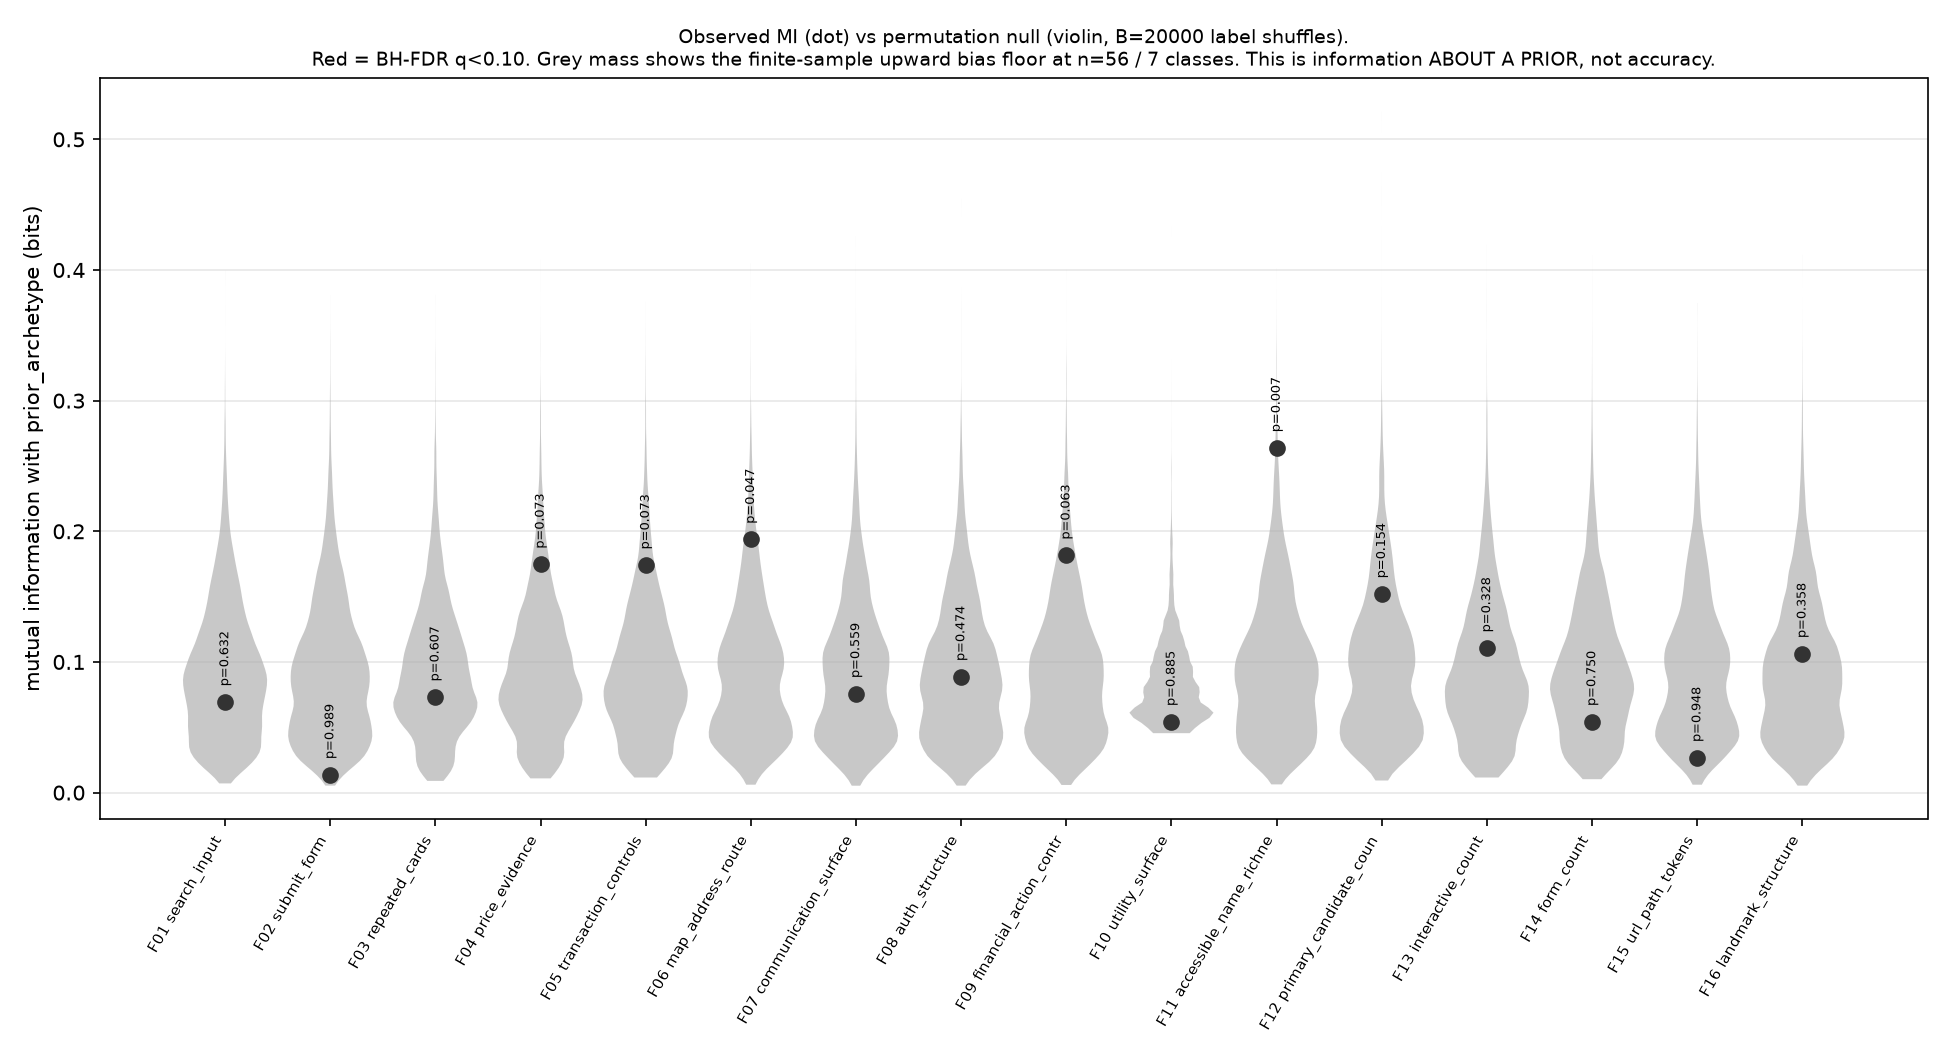

In [8]:
display(Image(filename=str(RD / "figures" / "RF2_B_mi_permutation.png")))

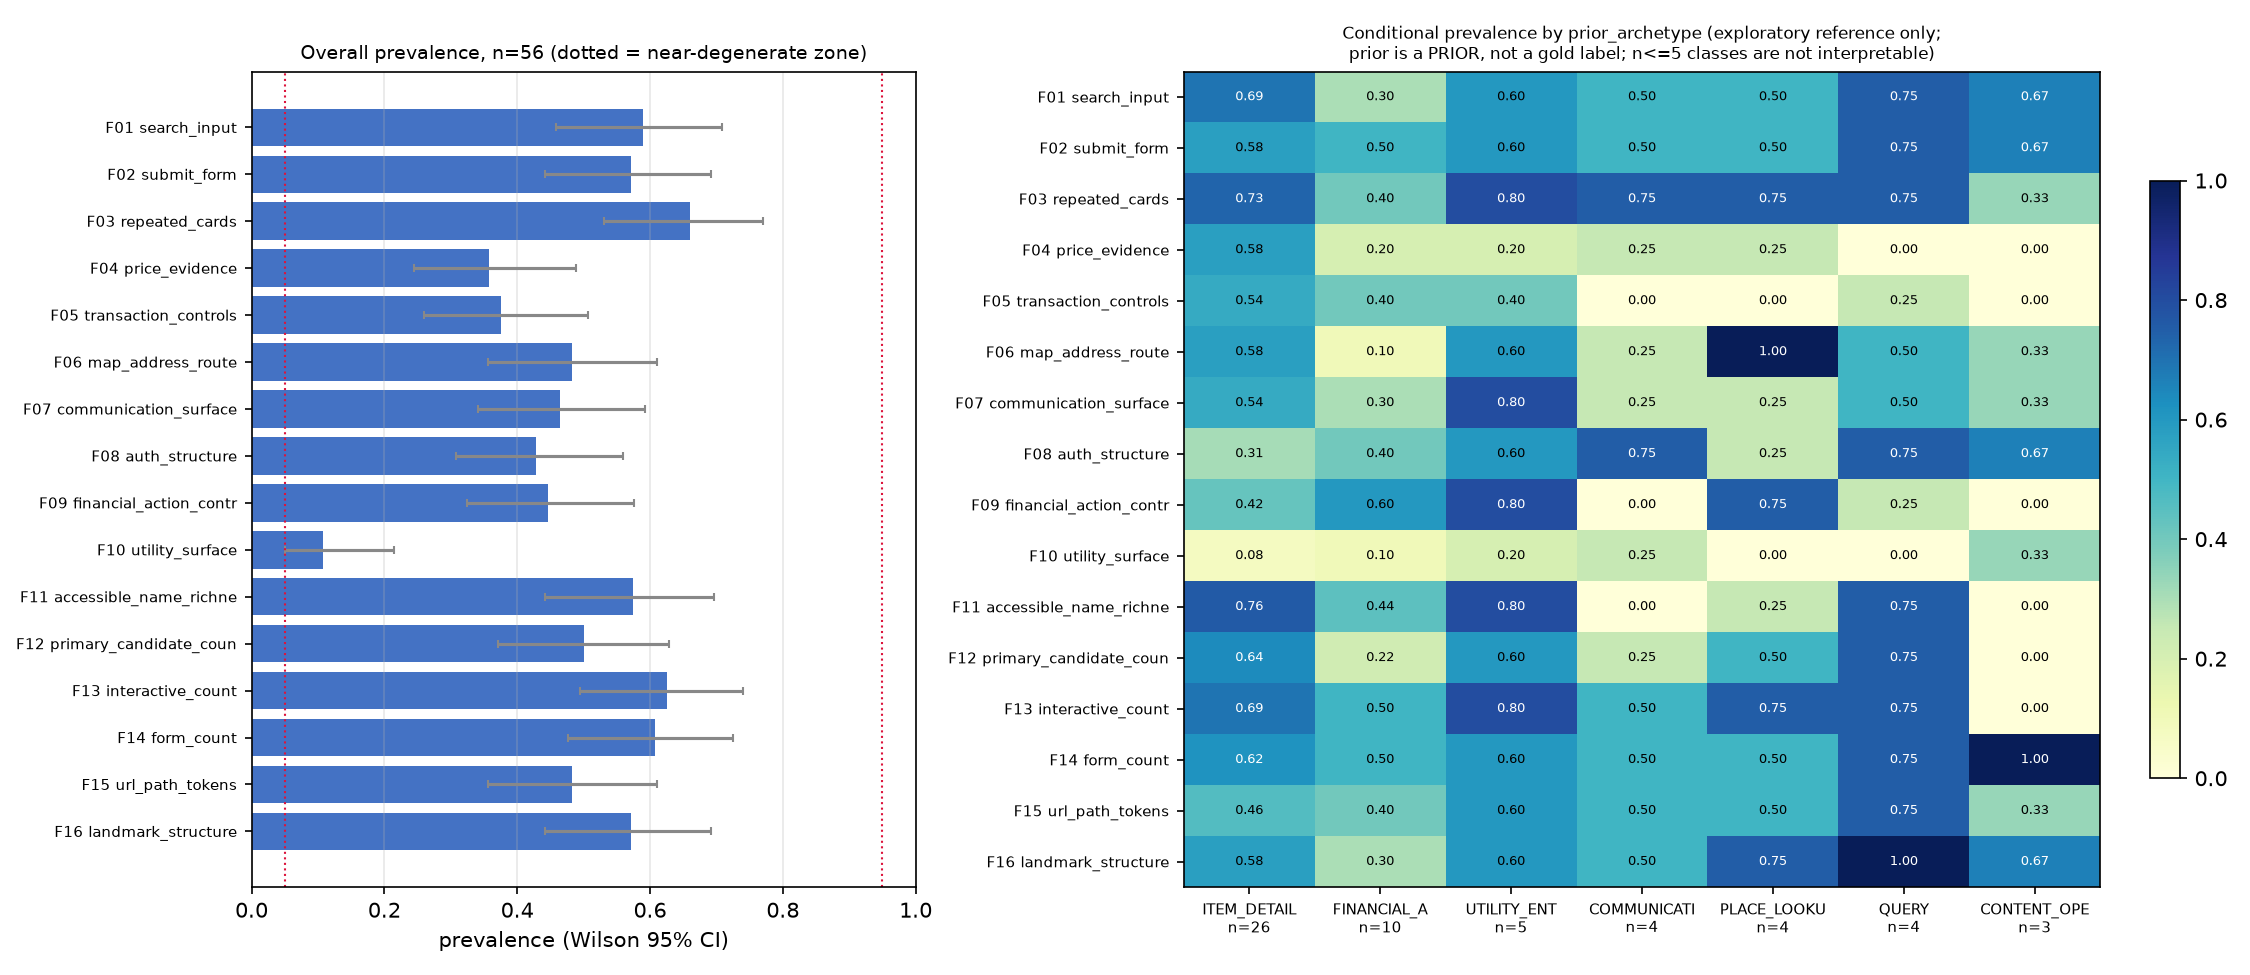

In [9]:
display(Image(filename=str(RD / "figures" / "RF2_B_prevalence.png")))

## 6. 반드시 답할 질문

### Q1. 어떤 feature 는 7-class 구별정보가 사실상 없는가?

In [10]:
A = D["answers"]
print("Tier A — 관측 MI 가 permutation null 평균에도 못 미침 (%d개):" % len(A["tier_A_zero_information_mi_at_or_below_null_mean"]))
for f in A["tier_A_zero_information_mi_at_or_below_null_mean"]:
    r = S[S.feature_id == f].iloc[0]
    print(f"  {f:<34} MI={r.mi_bits_plugin:.4f}  null={r.perm_null_mean_bits:.4f}  "
          f"excess={r.mi_excess_over_null_mean_bits:+.4f}  p={r.perm_p:.3f}")
print("\nTier B — BH-FDR(q<0.10) 통과 실패: %d/%d개 (전부)"
      % (len(A["tier_B_no_information_after_bh_fdr_q010"]), len(D["feature_specs"])))
print("Tier C — 무보정 p<0.05 이지만 FDR 실패:", A["tier_C_marginal_uncorrected_p_lt_005_but_fdr_fails"])
print("\nprevalence 가 거의 0 또는 거의 1 인 feature (degenerate):",
      A["degenerate_or_near_degenerate"] or "없음")
print("  → 정보가 없는 이유는 '다 있거나 다 없어서'가 아니다. 잘 갈라지는데 prior 와 정렬되지 않는다.")

Tier A — 관측 MI 가 permutation null 평균에도 못 미침 (8개):
  F01_search_input                   MI=0.0694  null=0.0921  excess=-0.0228  p=0.632
  F02_submit_form                    MI=0.0136  null=0.0921  excess=-0.0785  p=0.989
  F03_repeated_cards                 MI=0.0731  null=0.0931  excess=-0.0200  p=0.607
  F07_communication_surface          MI=0.0757  null=0.0920  excess=-0.0164  p=0.559
  F08_auth_structure                 MI=0.0887  null=0.0923  excess=-0.0036  p=0.474
  F10_utility_surface                MI=0.0542  null=0.0847  excess=-0.0305  p=0.885
  F14_form_count                     MI=0.0543  null=0.0929  excess=-0.0386  p=0.750
  F15_url_path_tokens                MI=0.0267  null=0.0927  excess=-0.0660  p=0.948

Tier B — BH-FDR(q<0.10) 통과 실패: 16/16개 (전부)
Tier C — 무보정 p<0.05 이지만 FDR 실패: ['F06_map_address_route', 'F11_accessible_name_richness']

prevalence 가 거의 0 또는 거의 1 인 feature (degenerate): 없음
  → 정보가 없는 이유는 '다 있거나 다 없어서'가 아니다. 잘 갈라지는데 prior 와 정렬되지 않는다.


### Q2. 정보량 상위 5개 (그래도 FDR 은 통과하지 못한다)

In [11]:
display(pd.DataFrame(A["top5_by_mi_excess_over_null"]).round(4))
print("채택 가능한(q<0.10) feature:", A["informative_features_ranked"] or "없음")

,feature_id,mi_bits,null_mean_bits,excess_bits,perm_p,perm_q_bh,normalized_mi,cramers_v
0,F11_accessible_name_richness,0.2638,0.0959,0.1680,0.0074,0.1184,0.1133,0.5587
1,F06_map_address_route,0.1937,0.0923,0.1015,0.0470,0.2331,0.0838,0.4723
2,F09_financial_action_controls,0.1816,0.0924,0.0892,0.0633,0.2331,0.0786,0.4493
3,F05_transaction_controls,0.1741,0.0930,0.0811,0.0728,0.2331,0.0753,0.4198
4,F04_price_evidence,0.1747,0.0938,0.0809,0.0725,0.2331,0.0756,0.4506


채택 가능한(q<0.10) feature: 없음


### Q3. 이진화가 신호를 죽였는가? — 3수준 순서변수 재계산

경계는 사전 확정값이다. 수준을 늘리면 MI 도 오르지만 **null 평균이 더 빨리 오른다**.

In [12]:
display(pd.DataFrame(D["ordinal_variants"]).round(4))

,feature_id,ordinal_source,cuts,levels,n,mi_bits_plugin,perm_null_mean_bits,mi_excess_over_null_mean_bits,perm_p,n_perm
0,F03_repeated_cards,card_count,"[0, 1, 8]",3,56,0.2054,0.1829,0.0225,0.3053,5000
1,F11_accessible_name_richness,n_accessible_name_sources,"[0, 50, 200]",3,54,0.2707,0.1967,0.0740,0.1428,5000
2,F12_primary_candidate_count,n_primary_action_candidates,"[0, 20, 100]",3,54,0.2248,0.1994,0.0254,0.3307,5000
3,F13_interactive_count,dom_interactive_n,"[0, 20, 100]",3,56,0.2562,0.1858,0.0703,0.1390,5000
4,F14_form_count,dom_input_n,"[0, 1, 4]",3,56,0.2370,0.1891,0.0479,0.2236,5000
5,F15_url_path_tokens,url_token_count,"[0, 4, 6]",3,56,0.1993,0.1872,0.0122,0.3903,5000


### Q4. 어떤 feature 쌍이 사실상 같은 것을 재고 있는가?

|phi| >= 0.60 인 쌍: 4


,a,b,phi,jaccard,exact_agreement,mi_bits
0,F02_submit_form,F14_form_count,0.925,0.941,0.963,0.772
1,F03_repeated_cards,F13_interactive_count,0.753,0.846,0.889,0.433
2,F11_accessible_name_richness,F12_primary_candidate_count,0.712,0.758,0.852,0.412
3,F11_accessible_name_richness,F13_interactive_count,0.699,0.784,0.852,0.385
4,F12_primary_candidate_count,F13_interactive_count,0.582,0.676,0.778,0.270
5,F01_search_input,F14_form_count,0.568,0.718,0.796,0.240
6,F01_search_input,F13_interactive_count,0.526,0.700,0.778,0.204
7,F01_search_input,F03_repeated_cards,0.523,0.707,0.778,0.200
8,F03_repeated_cards,F06_map_address_route,0.518,0.641,0.741,0.213
9,F02_submit_form,F08_auth_structure,0.514,0.600,0.741,0.207


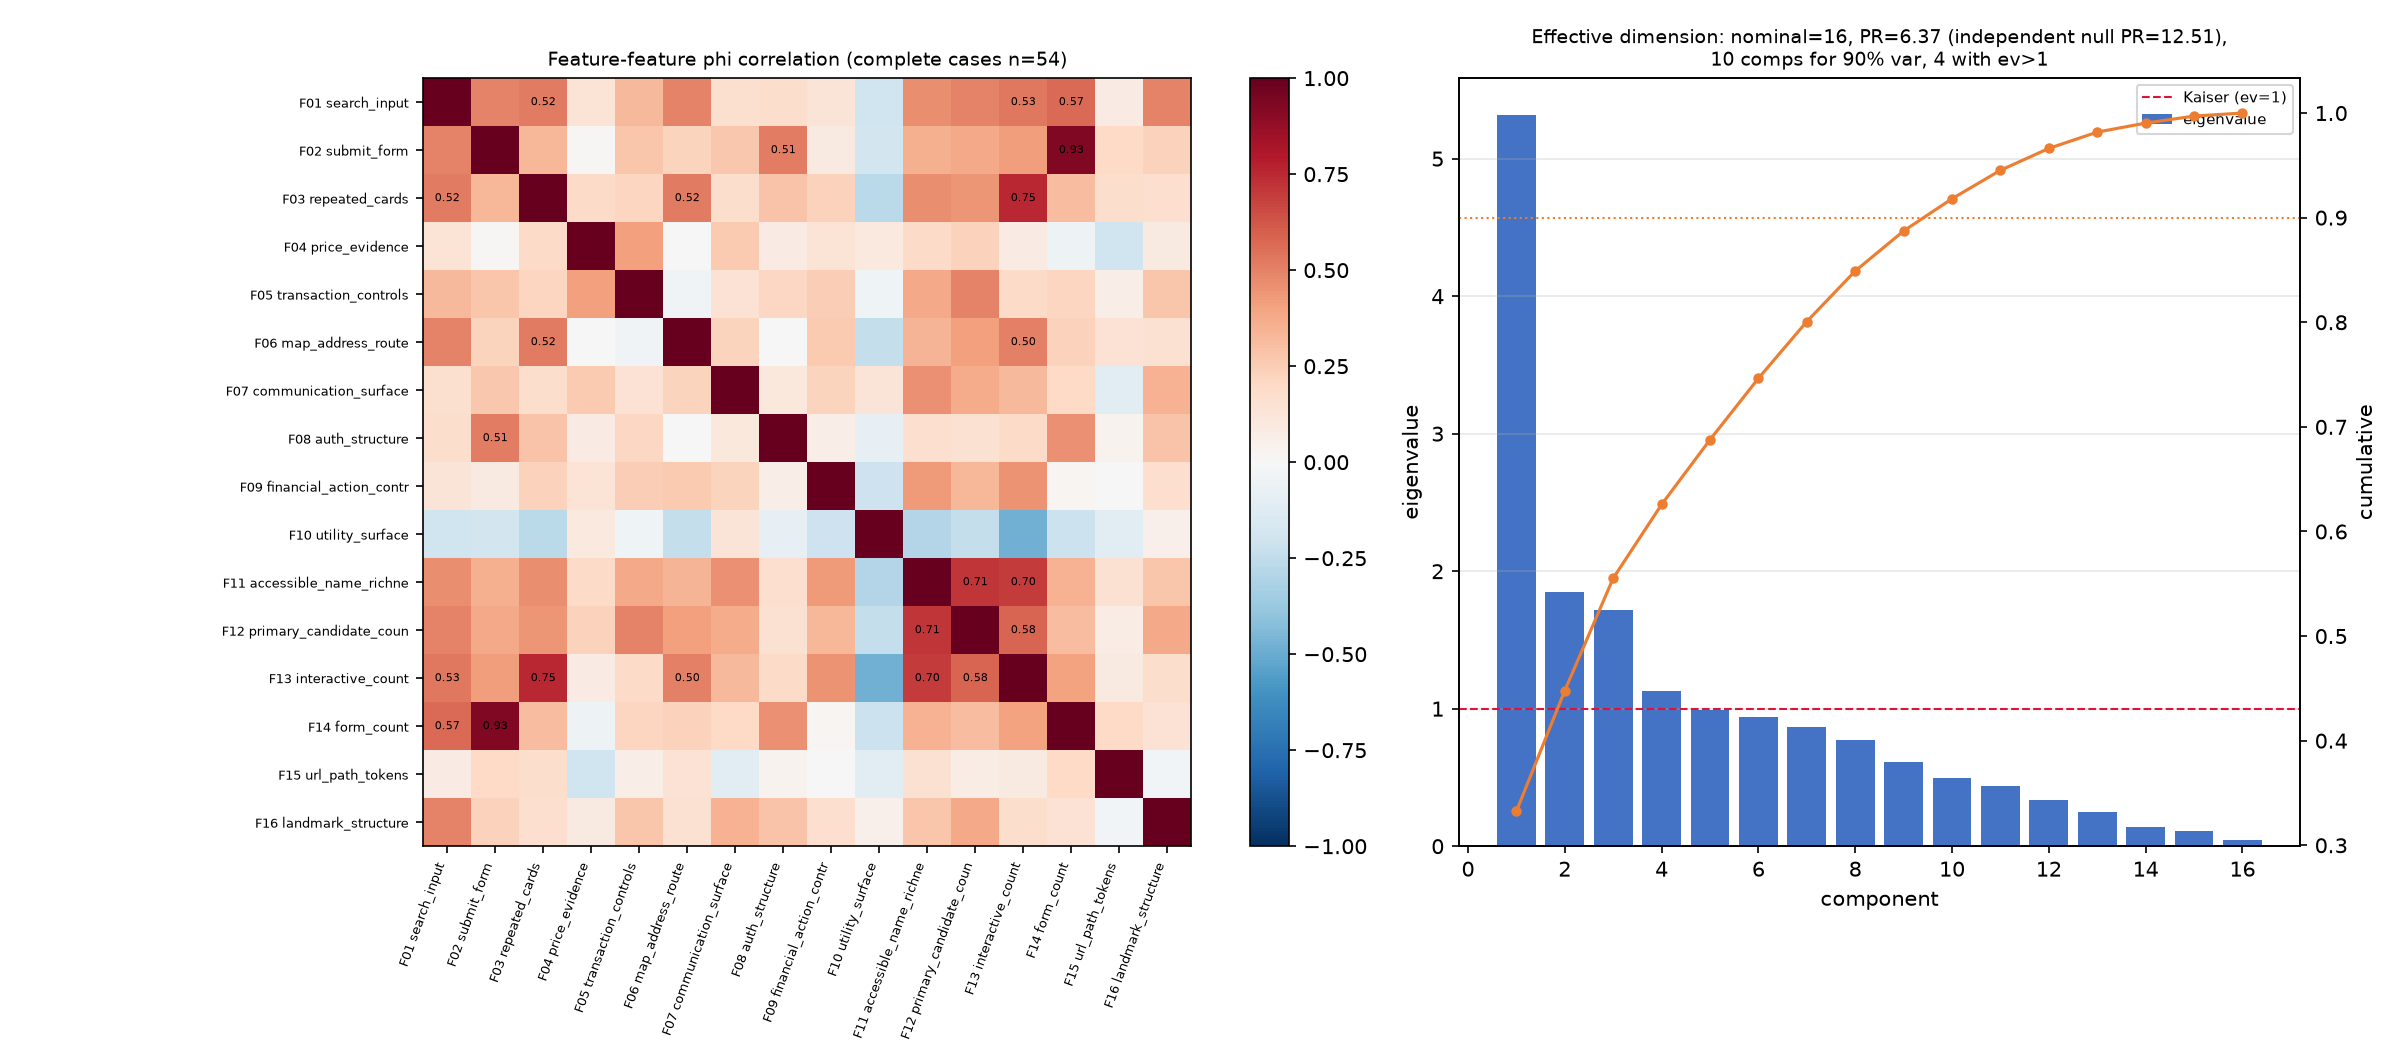

In [13]:
P = pd.DataFrame(D["redundancy"]["top_pairs_by_abs_phi"])
print("|phi| >= 0.60 인 쌍:", len(A["redundant_pairs_abs_phi_ge_060"]))
display(P.head(12).round(3))
display(Image(filename=str(RD / "figures" / "RF2_B_redundancy.png")))

### Q5. 선행 D 관측의 독립 재확인

선행 관측: `n_primary_action_candidates` 와 `n_target_size` 는 rho 0.999, 54건 중 30건 값이
정확히 동일.

{
 "claim": "n_primary_action_candidates 와 n_target_size 는 rho 0.999, 54건 중 30건 값이 정확히 동일",
 "independent_recheck": {
  "a": "n_primary_action_candidates",
  "b": "n_target_size",
  "n": 54,
  "spearman_rho": 0.9992552387918127,
  "pearson_r": 0.9693429848306266,
  "n_exact_equal": 30,
  "exact_equal_rate": 0.5555555555555556
 },
 "reproduced": true
}

정확일치율 100% 인 원시 컬럼 쌍 (수집기/마트 레이어 관측, D 평면은 고치지 않는다):


,a,b,n,spearman_rho,pearson_r,n_exact_equal,exact_equal_rate
0,modal_overlay_n,dismiss_control_n,54,1.0,1.0,54,1.0



원시 숫자 컬럼 중복 상위 10쌍:


,a,b,n,spearman_rho,pearson_r,n_exact_equal,exact_equal_rate
0,modal_overlay_n,dismiss_control_n,54,1.0000,1.0000,54,1.0000
1,n_primary_action_candidates,n_target_size,54,0.9993,0.9693,30,0.5556
2,dom_element_n,dom_body_element_n,56,0.9929,0.9997,0,0.0000
3,dom_interactive_n,dom_a_href_n,56,0.9835,0.9908,6,0.1071
4,n_contrast,gate_visible_text_len,54,0.9222,0.8751,0,0.0000
5,n_primary_action_candidates,n_contrast,54,0.9086,0.9526,1,0.0185
6,n_target_size,n_contrast,54,0.9076,0.9377,2,0.0370
7,n_primary_action_candidates,n_accessible_name_sources,54,0.8739,0.8600,0,0.0000
8,dom_interactive_n,dom_body_element_n,56,0.8726,0.8110,4,0.0714
9,n_target_size,n_accessible_name_sources,54,0.8715,0.8116,6,0.1111


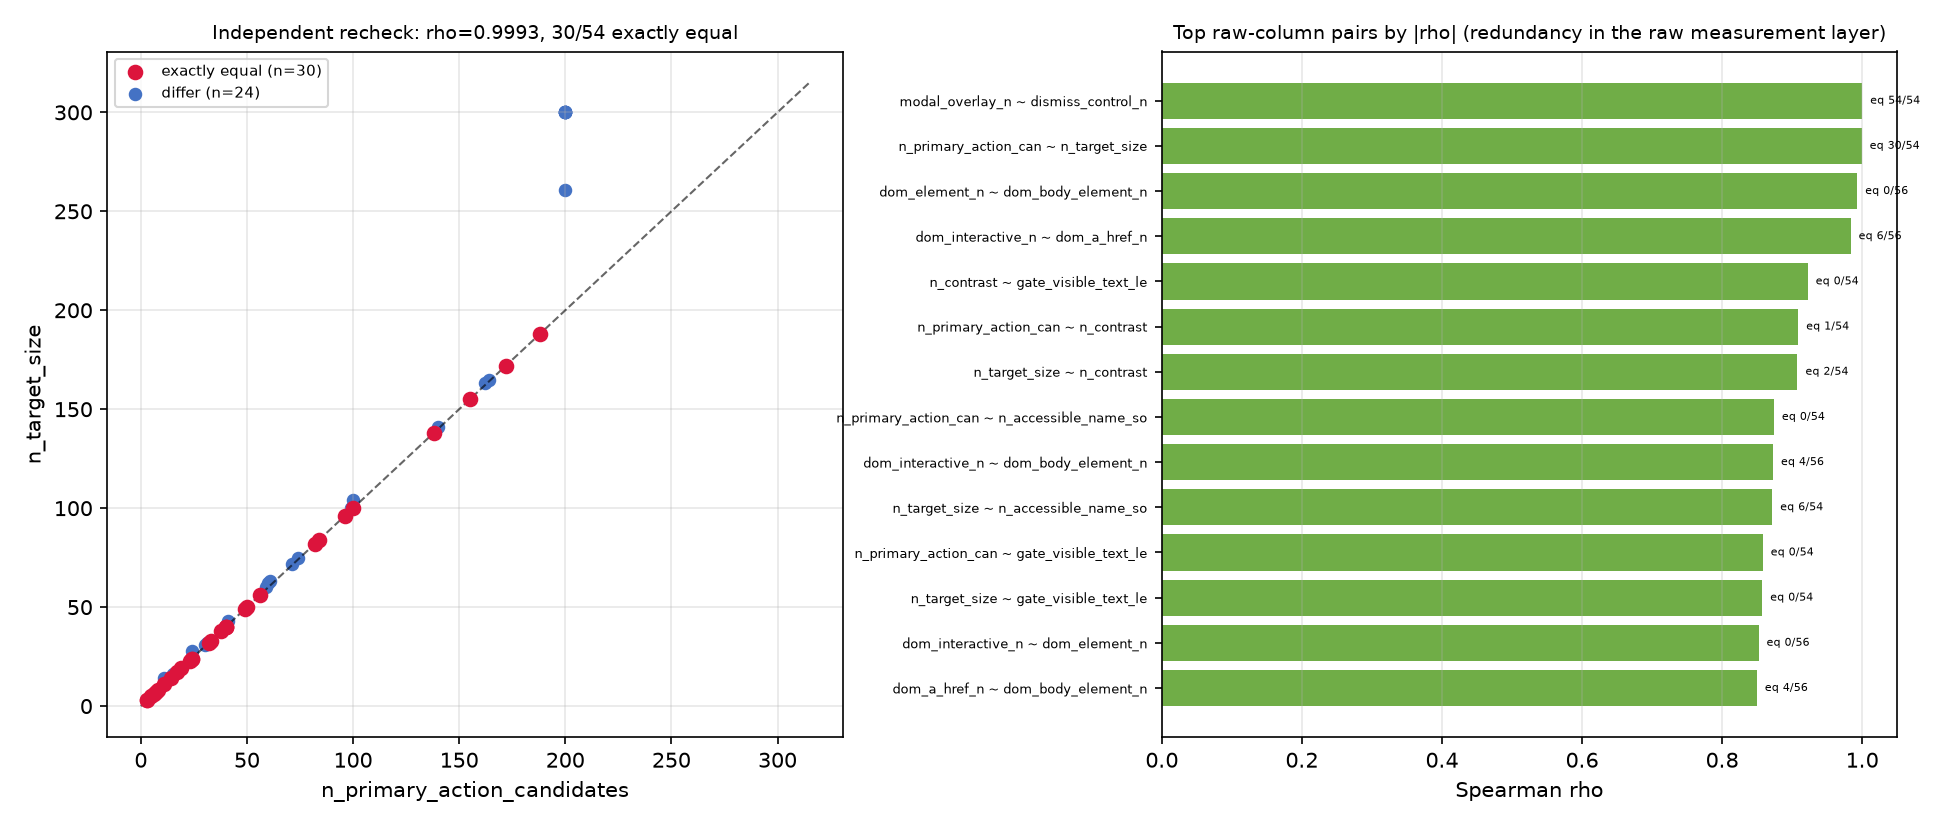

In [14]:
dup = D["duplicate_vector_recheck"]
print(json.dumps(dup["focal_prior_D_observation"], ensure_ascii=False, indent=1))
print("\n정확일치율 100% 인 원시 컬럼 쌍 (수집기/마트 레이어 관측, D 평면은 고치지 않는다):")
display(pd.DataFrame(dup["exact_duplicate_columns"]).round(4))
print("\n원시 숫자 컬럼 중복 상위 10쌍:")
display(pd.DataFrame(dup["pairs_top30"]).head(10).round(4))
display(Image(filename=str(RD / "figures" / "RF2_B_duplicate_vectors.png")))

## 7. 실효 차원

관측 participation ratio 를 **같은 주변분포·독립 열** null 과 비교한다. n=56 에서는 상관행렬
자체에 잡음이 있으므로 절대값이 아니라 이 비교가 근거다.

In [15]:
ed = A["effective_dimension"]
display(pd.DataFrame([ed]).T.rename(columns={0: "value"}))
R = D["redundancy"]
display(pd.DataFrame({"eigenvalue": R["eigenvalues"], "cumulative": R["cumulative_variance"]},
                     index=range(1, len(R["eigenvalues"]) + 1)).round(4))

,value
nominal,16.000000
participation_ratio,6.373959
independent_null_participation_ratio,12.511539
n_components_90pct,10.000000
n_components_kaiser,4.000000


,eigenvalue,cumulative
1,5.3197,0.3325
2,1.8462,0.4479
3,1.7182,0.5553
4,1.1289,0.6258
5,0.9904,0.6877
6,0.9388,0.7464
7,0.8683,0.8007
8,0.7731,0.8490
9,0.6135,0.8873
10,0.4928,0.9181


## 8. Verdict · limitation

전체 서술은 `research_d/results/RF2_B_FINDINGS.md` 에 있다 — 반례(§9), limitation(§11),
production implication(§12), 추가 연구질문(§13) 포함.

In [16]:
print("VERDICT:", D["verdict"])
print(D["verdict_note"])
print("\n가장 무거운 limitation: n=56 · 7 class · 최소 class n=3 에서 검정력이 근본적으로 부족하다.")
print("permutation null 평균이 0.09 bits 라는 것은, 그보다 작은 실제 효과는 어떤 추정량으로도")
print("보이지 않는다는 뜻이다. '정보 없음'과 '정보를 못 봄'이 이 표본에서는 구분되지 않는다.")
print("\n방화벽:", json.dumps(D["firewall"], ensure_ascii=False, indent=1))

VERDICT: PARTIALLY_SUPPORTED
H-B1 지지 + H-B3 지지, H-B2 미지지. 16개 feature 중 BH-FDR(q<0.10) 을 통과해 permutation null 을 넘는 feature 는 0개다. 동시에 실효 차원은 명목 차원보다 훨씬 작아 feature 들이 서로 같은 것을 재고 있다. 두 가설이 함께 성립하므로 단일 SUPPORTED 로 적지 않는다.

가장 무거운 limitation: n=56 · 7 class · 최소 class n=3 에서 검정력이 근본적으로 부족하다.
permutation null 평균이 0.09 bits 라는 것은, 그보다 작은 실제 효과는 어떤 추정량으로도
보이지 않는다는 뜻이다. '정보 없음'과 '정보를 못 봄'이 이 표본에서는 구분되지 않는다.

방화벽: {
 "opened_files": [
  "/home/sieg/projects-wsl/ProjectFinal/.agent_worktrees/claude_d_research/research/landing_accessibility/research_d/results/D_OBSERVATION_TABLE_v2.csv",
  "/home/sieg/projects-wsl/ProjectFinal/.agent_worktrees/claude_d_research/research/landing_accessibility/research_d/results/D_TEXT_CORPUS_v2.csv"
 ],
 "not_opened": "holdout label, LABEL_SPLIT_FROZEN*, HOLDOUT_FOR_C*, RAW_L1~L4*, PACKET_L*, *_OVERLAP*, PRECEDENCE_CONTESTED*, CALIBRATION_FOR_B*, **/control/**, B/C target-level holdout error report — 열지 않았다",
 "network": "none",
 "labels_produced": false,
 "produ